In [1]:
import numpy as np
import cv2

import PIL.Image as Image
import os

import matplotlib.pylab as plt

import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

C:\Users\user\anaconda3\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [34]:
IMAGE_SHAPE = (224, 224)

feature_extractor = hub.KerasLayer(
    "https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/100-224-classification/2",   # Standard version
    input_shape=IMAGE_SHAPE + (3,),
    
)

classifier = keras.Sequential([feature_extractor])


In [35]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)
# cache_dir indicates where to download data. I specified . which means current directory
# untar true will unzip it

In [36]:
data_dir


'.\\datasets\\flower_photos'

In [37]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flower_photos')

In [38]:
list(data_dir.glob('**/*.jpg'))[:5]

[WindowsPath('datasets/flower_photos/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172636503_21bededa75_n.jpg')]

In [39]:
image_count = len(list(data_dir.glob('**/*.jpg')))
print(image_count)

3670


In [40]:
roses = list(data_dir.glob('*/roses/*'))
roses[:5]

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

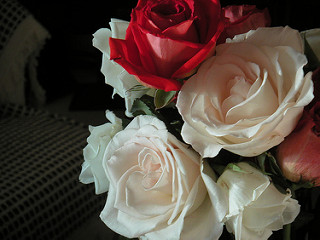

In [41]:
Image.open(str(roses[1]))

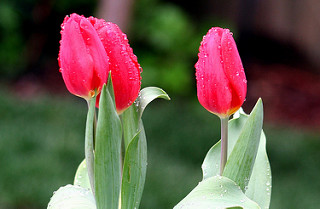

In [42]:
tulips = list(data_dir.glob('*/tulips/*'))
Image.open(str(tulips[0]))

In [43]:
flowers_images_dict = {
    'roses': list(data_dir.glob('*/roses/*')),
    'daisy': list(data_dir.glob('*/daisy/*')),
    'dandelion': list(data_dir.glob('*/dandelion/*')),
    'sunflowers': list(data_dir.glob('*/sunflowers/*')),
    'tulips': list(data_dir.glob('*/tulips/*')),
}

In [44]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [45]:
flowers_images_dict['roses'][:5]

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

In [46]:
str(flowers_images_dict['roses'][0])

'datasets\\flower_photos\\flower_photos\\roses\\10090824183_d02c613f10_m.jpg'

In [47]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))

In [48]:
img.shape

(240, 179, 3)

In [49]:
cv2.resize(img,IMAGE_SHAPE).shape

(224, 224, 3)

In [50]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [51]:
X = np.array(X)
y = np.array(y)

In [74]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [75]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [76]:
X[0].shape

(180, 180, 3)

In [77]:
IMAGE_SHAPE+(3,)

(224, 224, 3)

In [78]:
x0_resized = cv2.resize(X[0], IMAGE_SHAPE)
x1_resized = cv2.resize(X[1], IMAGE_SHAPE)
x2_resized = cv2.resize(X[2], IMAGE_SHAPE)

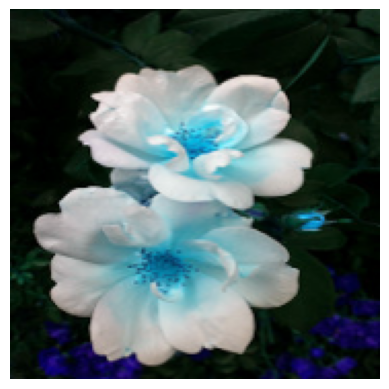

In [79]:
plt.axis('off')
plt.imshow(X[0])

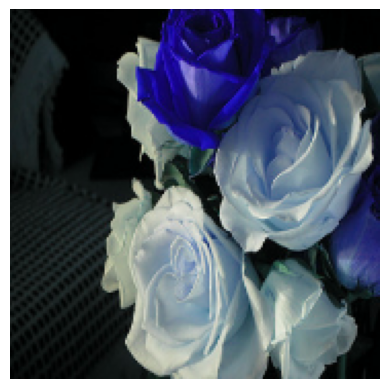

In [80]:
plt.axis('off')
plt.imshow(X[1])

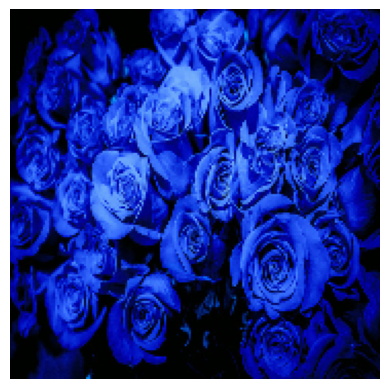

In [81]:
plt.axis('off')
plt.imshow(X[2])

In [82]:
predicted = classifier.predict(np.array([x0_resized, x1_resized, x2_resized]))
predicted = np.argmax(predicted, axis=1)
predicted

1/1 [==============================] - 1s 733ms/step


array([795, 795, 795])

In [83]:
feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

pretrained_model_without_top_layer = hub.KerasLayer(
    feature_extractor_model, input_shape=(224, 224, 3), trainable=False)

In [87]:
import tensorflow_hub as hub
import tf_keras as keras   # ← Important: Use tf_keras instead of tf.keras

num_of_flowers = 5

# Assuming 'pretrained_model_without_top_layer' is your hub.KerasLayer
model = keras.Sequential([
    keras.layers.Resizing(224, 224),
    pretrained_model_without_top_layer,     # This should be your hub.KerasLayer
    keras.layers.Dense(num_of_flowers, activation='softmax')
])


In [88]:
model.compile(
  optimizer="adam",
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['acc'])

model.fit(X_train_scaled, y_train, epochs=5)

Epoch 1/5


C:\Users\user\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\nn.py:1216: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


86/86 [==============================] - 76s 584ms/step - loss: 0.8305 - acc: 0.6860
Epoch 2/5
86/86 [==============================] - 45s 518ms/step - loss: 0.4340 - acc: 0.8423
Epoch 3/5
86/86 [==============================] - 44s 507ms/step - loss: 0.3367 - acc: 0.8837
Epoch 4/5
86/86 [==============================] - 44s 512ms/step - loss: 0.2836 - acc: 0.9084
Epoch 5/5
86/86 [==============================] - 48s 553ms/step - loss: 0.2472 - acc: 0.9215


In [89]:
model.evaluate(X_test_scaled,y_test)

29/29 [==============================] - 22s 623ms/step - loss: 0.4072 - acc: 0.8551


[0.4072464108467102, 0.8551198244094849]